In [1]:
library(DESeq2)
library(SummarizedExperiment)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [2]:
featurecounts <- read.table("/usr/users/papantonis1/aman/rnaseq_data/irnaseq_results/all_samples_counts_exons.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Extract *only* count columns — from column 9 onwards
counts_introns <- featurecounts[, 9:ncol(featurecounts)]

# Rename columns to match samples
colnames(counts_introns) <- c("S55", "S56", "S57", "S58", "S59", "S60")

# Set rownames to gene symbols (or RefSeq if preferred)
rownames(counts_introns) <- featurecounts$Symbol

counts_introns

,S55,S56,S57,S58,S59,S60
,<int>,<int>,<int>,<int>,<int>,<int>
NAT2,3,14,8,2,10,0
ACADS,481,473,335,318,290,202
ACAT1,946,1251,816,908,858,658
ACVRL1,0,0,1,4,1,2
PSEN1,2947,3491,4182,4052,3451,2774
SGCA,10,10,0,0,0,0
ADRB2,10,4,6,17,4,2
ADRB3,10,5,0,0,0,2
AGXT,8,4,2,6,1,3


In [3]:
dim(counts_introns)

[1] 19101     6

In [4]:
colnames(counts_introns)

[1] "S55" "S56" "S57" "S58" "S59" "S60"

In [5]:
condition <- factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control"),
                    levels = c("control", "CPI", "AuxinCPI"))

# control is the reference level

In [6]:
coldata <- data.frame(row.names = colnames(counts_introns),
                      condition = condition)
coldata

,condition
,<fct>
S55,AuxinCPI
S56,AuxinCPI
S57,CPI
S58,CPI
S59,control
S60,control


In [7]:
dds <- DESeqDataSetFromMatrix(countData = counts_introns,
                              colData = coldata,
                              design = ~ condition)

# design formula - gene expression based on the levels of the condition factor.

In [8]:
dds$condition <- relevel(dds$condition, ref = "control")
# Setting the reference level of the factor condition in the dds object to "control"

In [9]:
levels(dds$condition)

[1] "control"  "CPI"      "AuxinCPI"

In [10]:
dds <- DESeq(dds)
res <- results(dds, contrast = c("condition", "CPI", "control"))
res

# Fitting the negative binomial model and wald test for each gene comparing CPI vs control

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 19101 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat      pvalue      padj
        <numeric>      <numeric> <numeric>  <numeric>   <numeric> <numeric>
NAT2      6.04317     -0.0376902  1.833111 -0.0205608   0.9835960        NA
ACADS   358.77030      0.2479963  0.226612  1.0943661   0.2737945        NA
ACAT1   915.23853      0.0189060  0.158989  0.1189138   0.9053436  0.959043
ACVRL1    1.21883      0.5050964  3.348617  0.1508373   0.8801040        NA
PSEN1  3427.81124      0.2332300  0.101721  2.2928415   0.0218571  0.141381
...           ...            ...       ...        ...         ...       ...
HJV       1.55177      -2.480189  4.079089  -0.608025 0.543170815        NA
KRT39     0.00000             NA        NA         NA          NA        NA
TPM2     88.25851      -1.670947  0.501122  -3.334412 0.000854798        NA
RPLP1  5207.64705       0.334

In [11]:
summary(res)


out of 17190 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 670, 3.9%
LFC < 0 (down)     : 250, 1.5%
outliers [1]       : 0, 0%
low counts [2]     : 9608, 56%
(mean count < 528)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



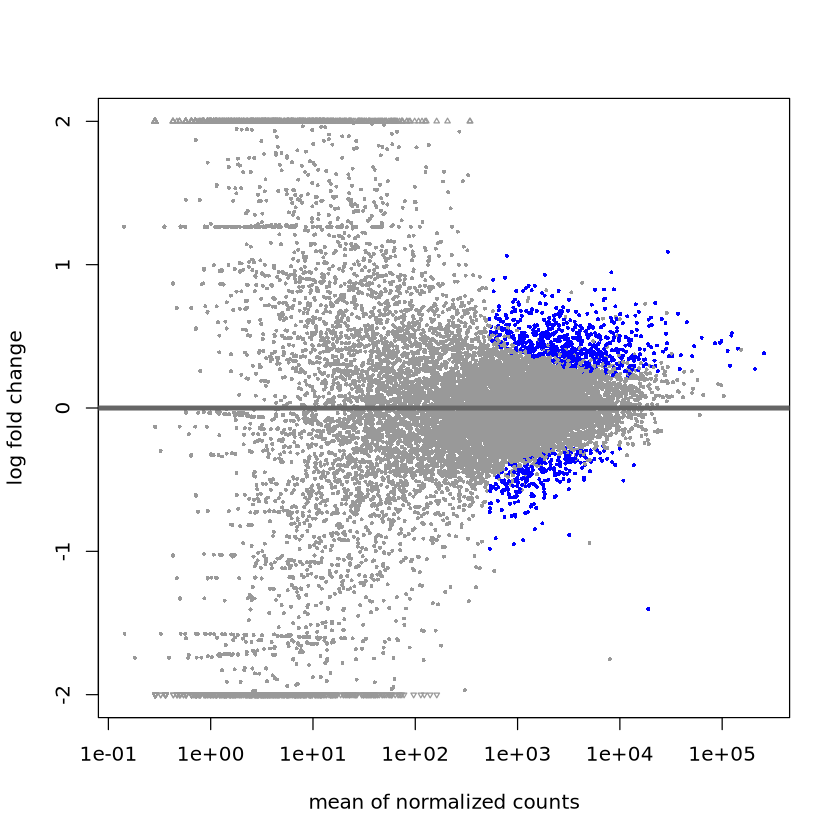

In [12]:
plotMA(res, ylim=c(-2,2))

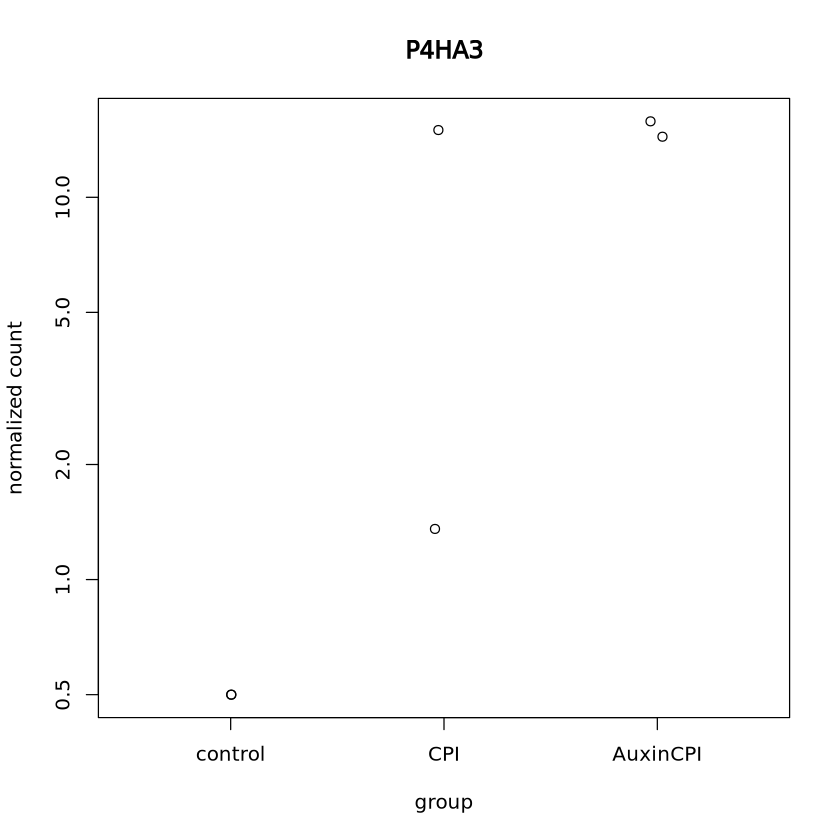

In [13]:
plotCounts(dds, gene=which.max(res$log2FoldChange), intgroup="condition")

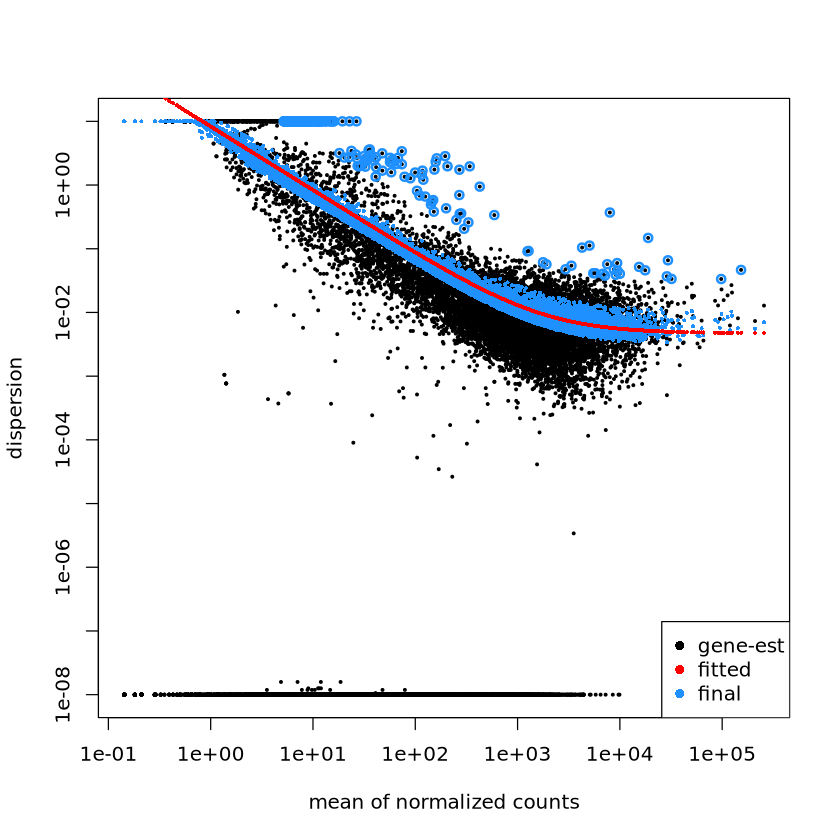

In [14]:
plotDispEsts(dds)

In [15]:
vsd <- vst(dds, blind=FALSE)

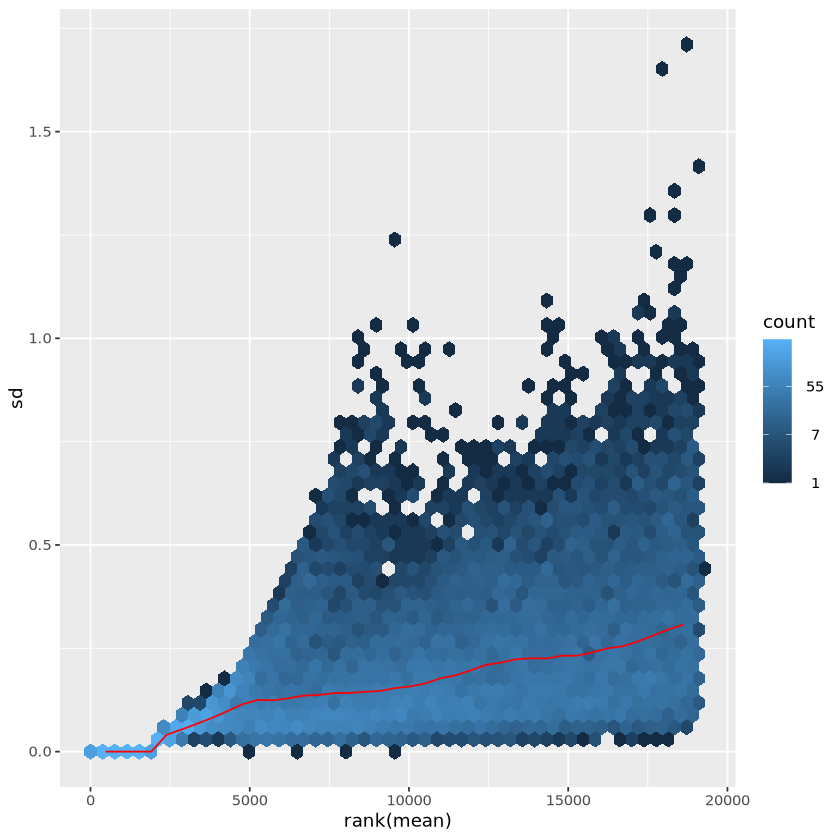

In [16]:
library("vsn")
meanSdPlot(assay(vsd))

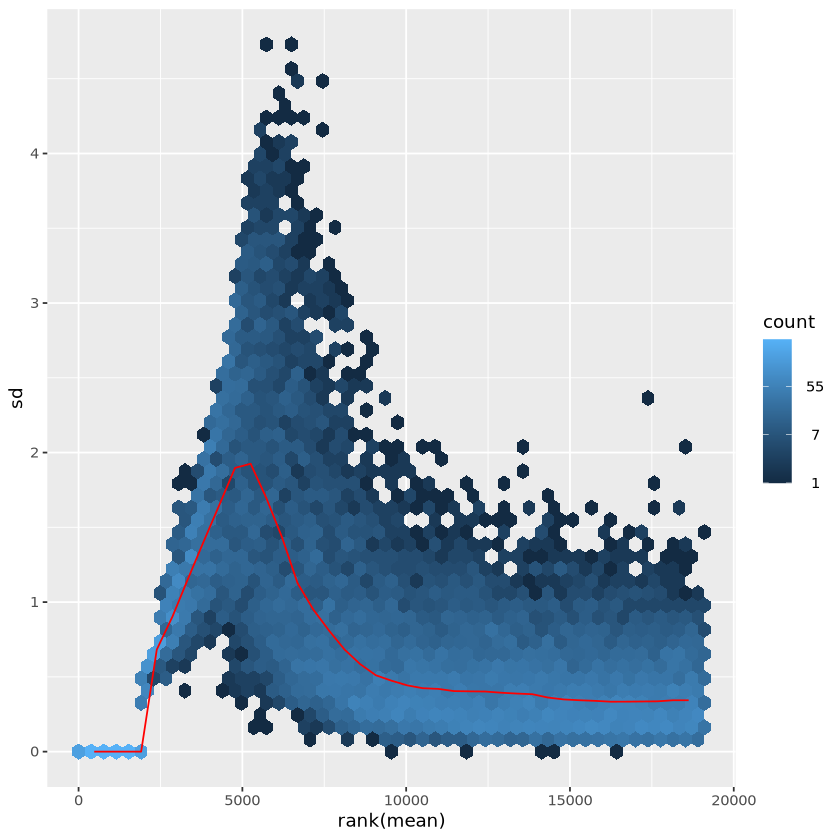

In [17]:
ntd <- normTransform(dds)
meanSdPlot(assay(ntd))

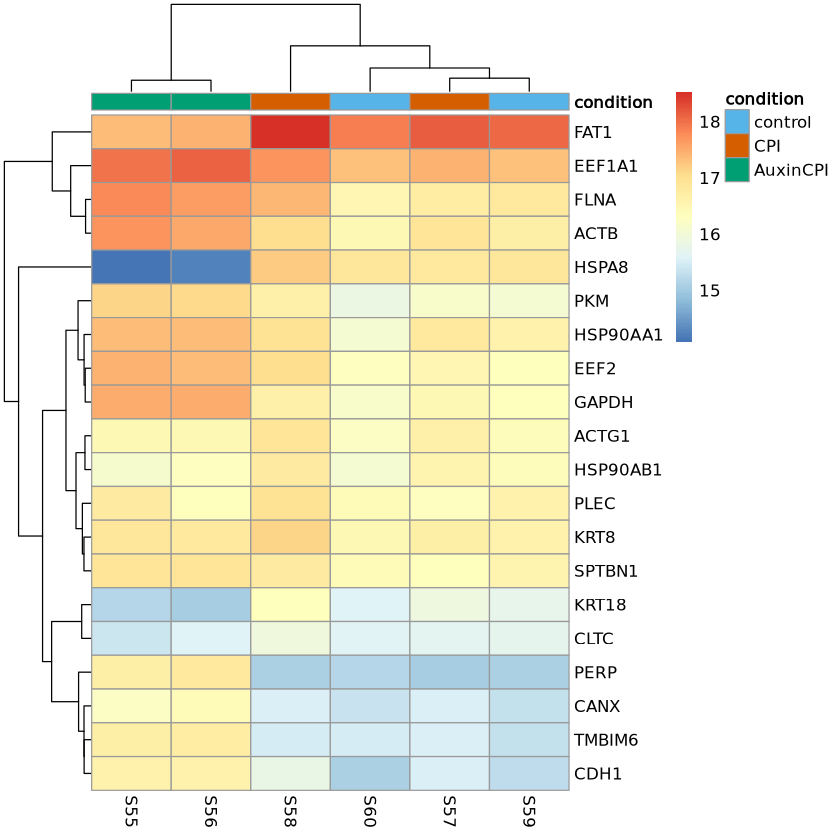

In [39]:
library("pheatmap")

select <- order(rowMeans(counts(dds, normalized=TRUE)), decreasing=TRUE)[1:20]


# Reassign colnames and ensure annotation matches order
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
df <- as.data.frame(colData(dds)[, "condition", drop = FALSE])
rownames(df) <- colnames(vsd)
df$condition <- factor(df$condition, levels = c("control", "CPI", "AuxinCPI"))



# Define annotation colors
ann_colors <- list(
  condition = c("control" = "#56B4E9", "CPI" = "#D55E00", "AuxinCPI" = "#009E73")
)

pheatmap(
  assay(ntd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)


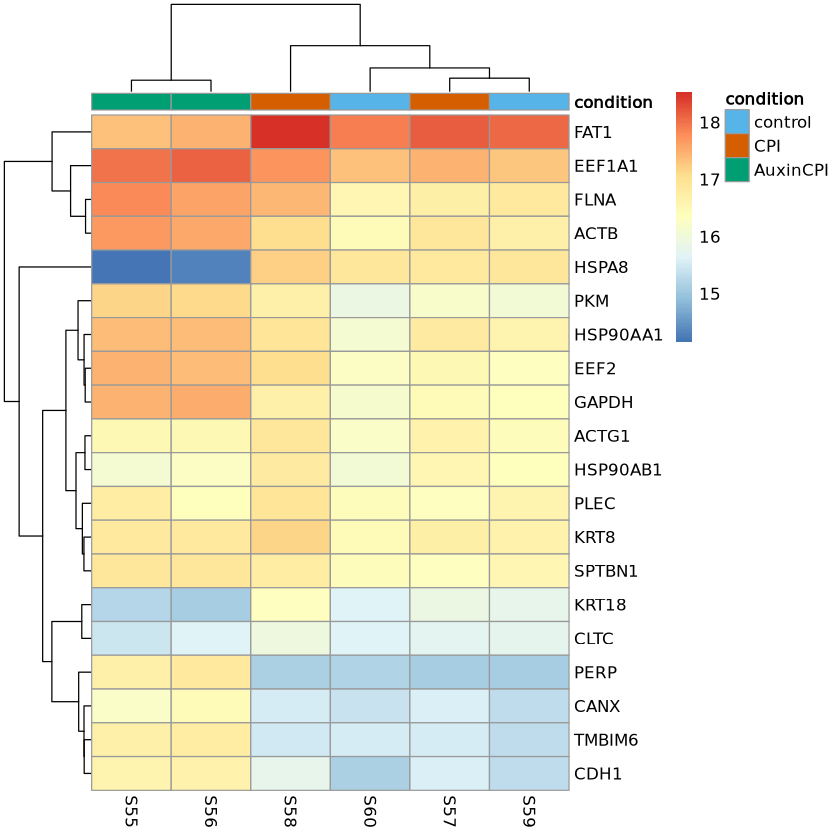

In [40]:
### VST

colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
pheatmap(
  assay(vsd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)

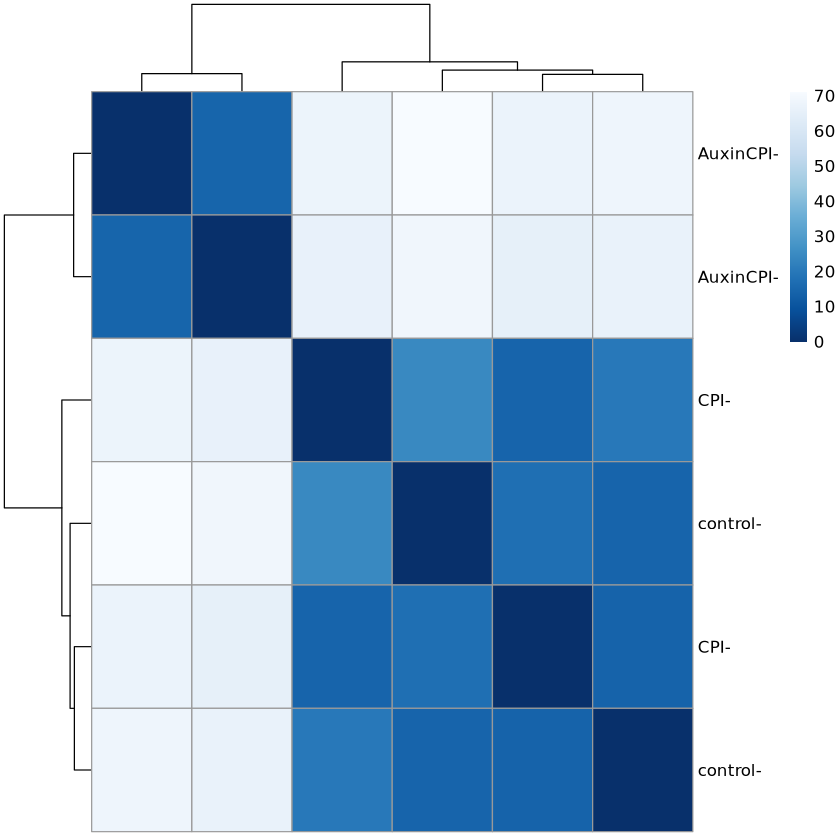

In [20]:
sampleDists <- dist(t(assay(vsd)))
library("RColorBrewer")
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$condition, vsd$type, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

# control and cpi correlated which in a way makes sense biologically

In [21]:
#plotPCA(vsd, intgroup=c("condition"))
pca <- prcomp(t(assay(vsd)))
summary(pca)


Importance of components:
                           PC1     PC2     PC3     PC4     PC5       PC6
Standard deviation     34.2167 7.97979 4.91573 3.78660 3.60038 8.211e-14
Proportion of Variance  0.9105 0.04952 0.01879 0.01115 0.01008 0.000e+00
Cumulative Proportion   0.9105 0.95998 0.97877 0.98992 1.00000 1.000e+00

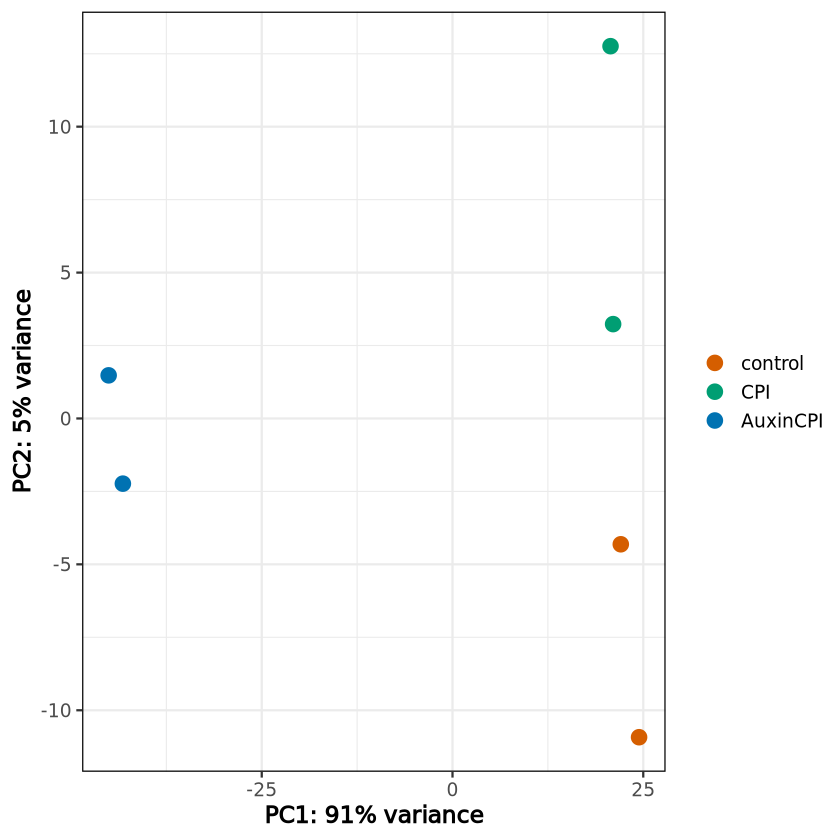

In [22]:
library(ggplot2)

# Extract PCA coordinates
pca_data <- as.data.frame(pca$x)
pca_data$condition <- colData(vsd)$condition  # Add condition info

# Variance labels
percentVar <- round(100 * summary(pca)$importance[2, 1:2], 1)

# Plot
ggplot(pca_data, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("control" = "#D55E00", "CPI" = "#009E73", "AuxinCPI" = "#0072B2")) +
  theme(
    panel.border = element_rect(color = "black", linewidth = 0.7),
    axis.title = element_text(face = "bold"),
    legend.title = element_blank()
  )


In [23]:
resultsNames(dds)

[1] "Intercept"                     "condition_CPI_vs_control"     
[3] "condition_AuxinCPI_vs_control"

In [24]:
resLFC <- lfcShrink(dds, coef="condition_CPI_vs_control", type="apeglm")
resLFC

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 19101 rows and 5 columns
         baseMean log2FoldChange     lfcSE      pvalue      padj
        <numeric>      <numeric> <numeric>   <numeric> <numeric>
NAT2      6.04317   -0.000157841 0.1224685   0.9835960        NA
ACADS   358.77030    0.061704242 0.1238915   0.2737945        NA
ACAT1   915.23853    0.007015059 0.0973053   0.9053436  0.959043
ACVRL1    1.21883    0.000820696 0.1226659   0.8801040        NA
PSEN1  3427.81124    0.175613286 0.1019410   0.0218571  0.141381
...           ...            ...       ...         ...       ...
HJV       1.55177    -0.00250343  0.122762 0.543170815        NA
KRT39     0.00000             NA        NA          NA        NA
TPM2     88.25851    -1.28485778  0.597185 0.000854798        NA
RPLP1  5207.64705     0.23034574  0.146473 0.014750859  0.111618
PRR27     0.00000             NA        NA          NA        NA

In [25]:
# order based on the pval
resOrdered <- res[order(res$pvalue),]
resOrdered

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 19101 rows and 6 columns
          baseMean log2FoldChange     lfcSE      stat      pvalue        padj
         <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
SLC30A1    8250.28       0.945631  0.104048   9.08841 1.00497e-19 7.61971e-16
NUCB1      1842.90       0.929837  0.142999   6.50239 7.90538e-11 2.99693e-07
PARM1     10080.79       0.657864  0.102220   6.43580 1.22826e-10 3.10423e-07
SLC39A10   2185.68       0.780577  0.126701   6.16076 7.23959e-10 1.37226e-06
GRN        5725.68       0.825682  0.139121   5.93501 2.93829e-09 4.45563e-06
...            ...            ...       ...       ...         ...         ...
DEFB132          0             NA        NA        NA          NA          NA
ERVFRD-1         0             NA        NA        NA          NA          NA
AMTN             0             NA        NA        NA          NA          NA
KRT39  

In [26]:
# filtering with padj < 0.05
sum(res$padj < 0.05, na.rm=TRUE)

[1] 609

In [27]:
res_raw <- results(dds, contrast = c("condition", "CPI", "control"))

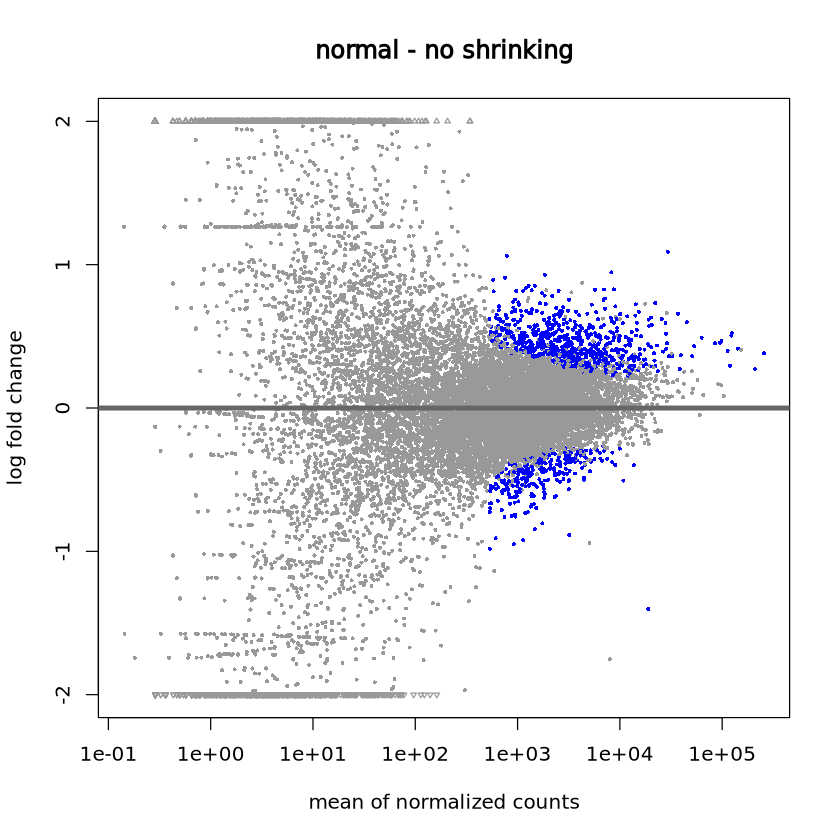

In [28]:
plotMA(res_raw, ylim=c(-2,2), main="normal - no shrinking")

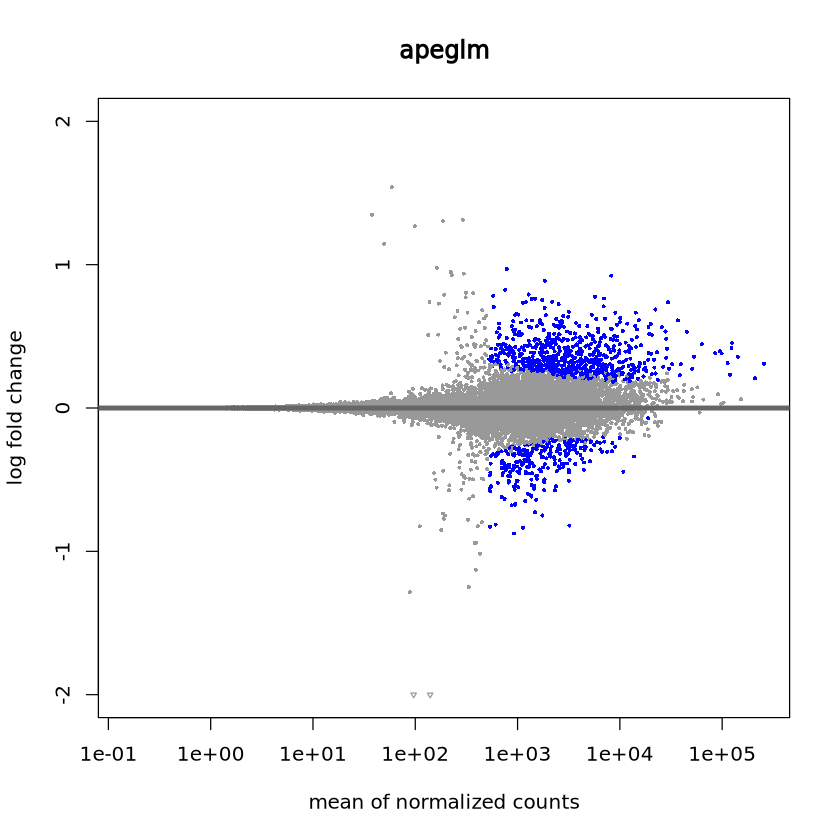

In [29]:
plotMA(resLFC, ylim=c(-2,2), main="apeglm")

In [30]:
sig_res <- res[which(res$padj < 0.05), ]

In [31]:
sig_res

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 609 rows and 6 columns
        baseMean log2FoldChange     lfcSE      stat      pvalue        padj
       <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
FUCA1   6304.722       0.364782  0.107155   3.40425 0.000663466   0.0164392
INSR     904.142       0.488830  0.168643   2.89862 0.003748129   0.0476817
MET     9335.338       0.309308  0.098324   3.14580 0.001656340   0.0290703
NPC1    3123.820       0.431482  0.122906   3.51067 0.000446975   0.0130848
PKD1    5231.323      -0.376001  0.127755  -2.94313 0.003249106   0.0443972
...          ...            ...       ...       ...         ...         ...
KRT18  53142.611       0.431550  0.132587   3.25484 1.13458e-03 2.30010e-02
E2F7     823.242      -0.510514  0.164355  -3.10617 1.89525e-03 3.19327e-02
MAMDC4   609.969      -0.908359  0.200855  -4.52246 6.11246e-06 8.13064e-04
TSEN54   807.207      -0.571156

In [32]:
upregulated <- sig_res[which(sig_res$log2FoldChange > 0.6), ]
up_genes <- rownames(upregulated)

In [33]:
downregulated <- sig_res[which(sig_res$log2FoldChange < - 0.6), ]
down_genes <- rownames(downregulated)

In [34]:
length(up_genes)

[1] 94

In [35]:
length(down_genes)

[1] 37

In [36]:
up_df <- data.frame(
  ensembl = rownames(upregulated),
  log2FC = upregulated$log2FoldChange
)

write.table(up_df, file = "upregulated_genes_exons_irnaseqCM.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [37]:
down_df <- data.frame(
  ensembl = rownames(downregulated),
  log2FC = downregulated$log2FoldChange
)
write.table(down_df, file = "downregulated_genes_exons_irnaseqCM.txt", sep = "\t", quote = FALSE, row.names = FALSE)

Loading required package: ggrepel



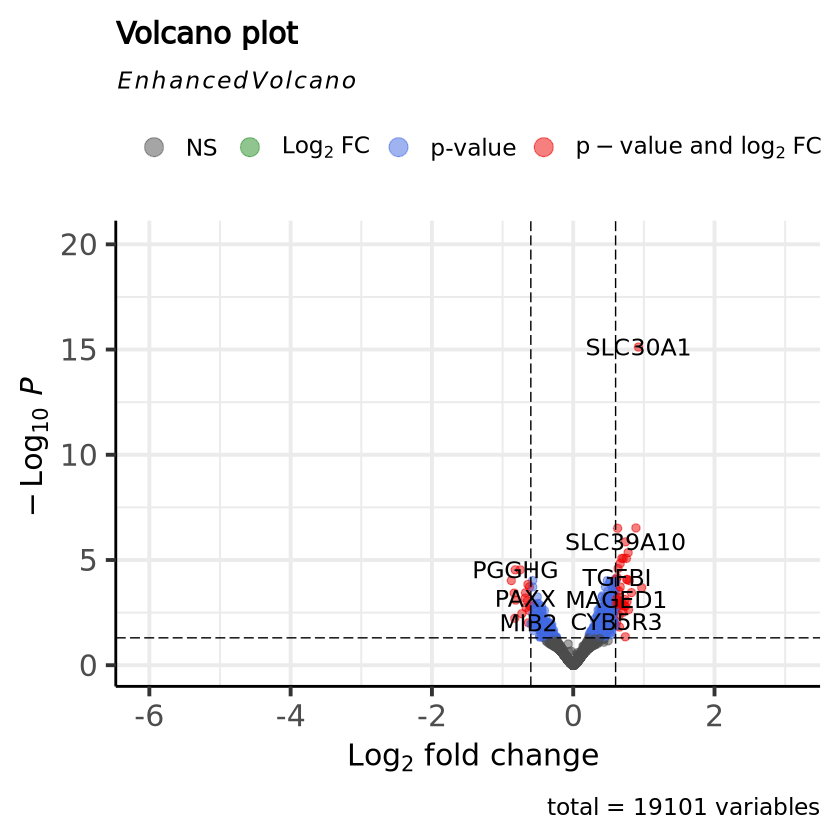

In [38]:
library(EnhancedVolcano)
EnhancedVolcano(resLFC,
  lab = rownames(resLFC),
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 0.6)

# resLFC used as it is the shrunk one